### Snapp Pay!


Anomaly detection Using Z-Score:

You have data for SnappGroup! customers. You are asked to calculate the z-score for each customer and, based on these z-scores, determine which customers are outliers in terms of high default risk.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import display
import scipy.stats as stats


Load the data using pandas and take an initial overview.


In [33]:
df = pd.read_csv('snapp.csv')
display(df)

,POD,AvgSpentOnSnappFood
0,0.095239,2.931748e+06
1,0.105493,3.517870e+06
2,0.123370,3.481772e+06
3,0.141007,3.531373e+06
4,0.102860,3.440841e+06
...,...,...
4938,0.690868,2.511905e+06
4939,0.698361,2.501296e+06
4940,0.690682,3.289862e+06
4941,0.701937,2.676932e+06


In [34]:
df.head()

,POD,AvgSpentOnSnappFood
0,0.095239,2.931748e+06
1,0.105493,3.517870e+06
2,0.123370,3.481772e+06
3,0.141007,3.531373e+06
4,0.102860,3.440841e+06


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   POD                  4943 non-null   float64
 1   AvgSpentOnSnappFood  4943 non-null   float64
dtypes: float64(2)
memory usage: 77.4 KB


Let's create some visualizations to gain more insights into the data:


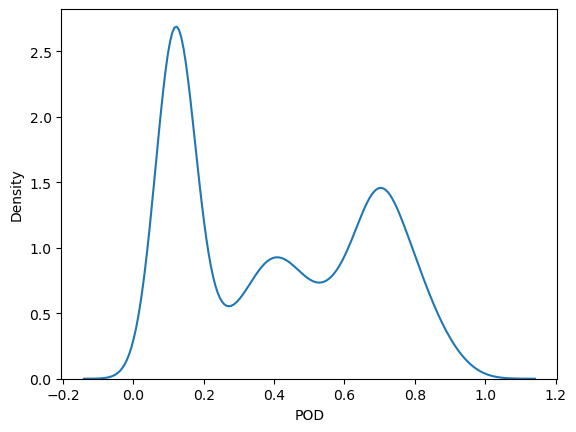

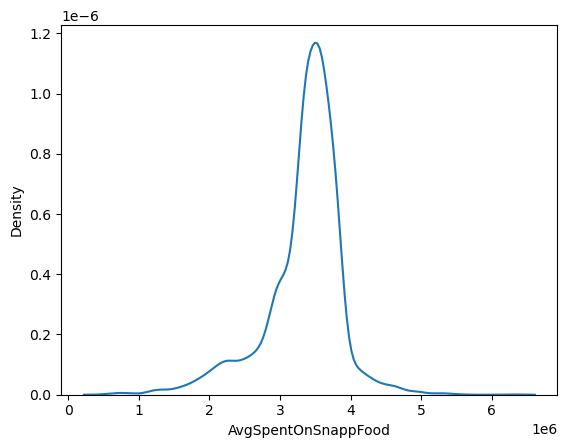

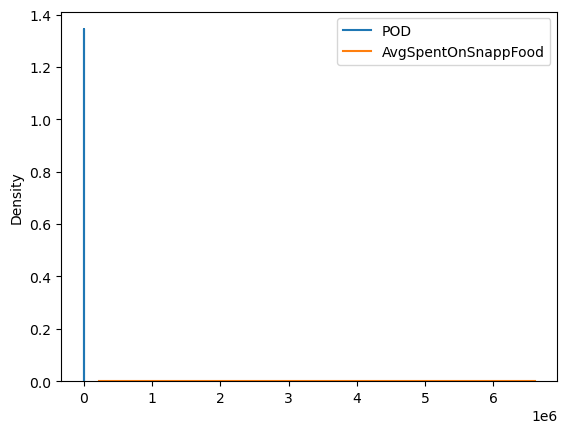

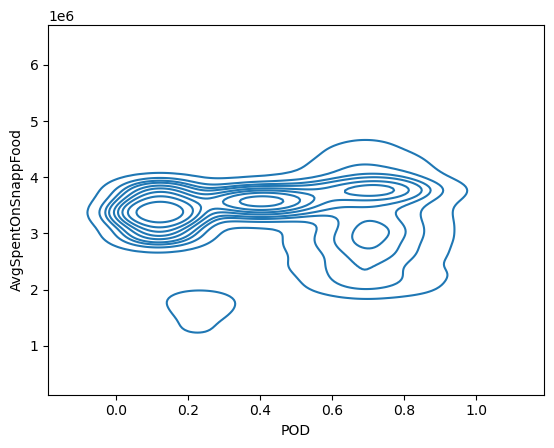

In [36]:
# For AvgSpentOnSnappFood
# For PODs

sns.kdeplot(df['POD'])
plt.show()

sns.kdeplot(df['AvgSpentOnSnappFood'])
plt.show()

sns.kdeplot(df[['POD', 'AvgSpentOnSnappFood']])
plt.show()

sns.kdeplot(x=df['POD'], y=df['AvgSpentOnSnappFood'])
plt.show()

According to z-score formula, calculate the z-score for the 'AvgSpentOnSnappFood' column per user,
<br/>
and add the z-score values as a new column named "z-score" to the data


In [37]:
# YOUR CODE HERE

df["ASOS-z-score"] = df[['AvgSpentOnSnappFood']].apply(stats.zscore)
df.head()


,POD,AvgSpentOnSnappFood,ASOS-z-score
0,0.095239,2.931748e+06,-0.749173
1,0.105493,3.517870e+06,0.325485
2,0.123370,3.481772e+06,0.259298
3,0.141007,3.531373e+06,0.350242
4,0.102860,3.440841e+06,0.184252


Plot the distribution of z-scores:


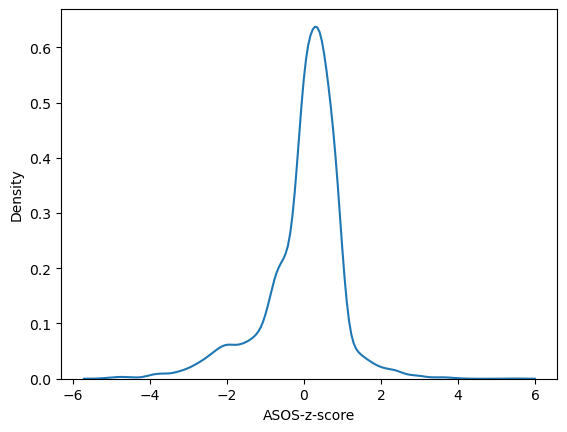

In [38]:
# YOUR CODE HERE

sns.kdeplot(df['ASOS-z-score'])
plt.show()

We want to analyze the behavior of abnormal users.
<br/>
How we can detect anomalies based on z-score? Find them and store them in a new dataframe called "anomalies"!


In [39]:
# YOUR CODE HERE

ASOS_anomalies = pd.DataFrame(abs(df['ASOS-z-score'])>=1)
display(ASOS_anomalies)

ASOS_true_count = ASOS_anomalies.values.sum()
print("Total True values in DataFrame:", ASOS_true_count)


,ASOS-z-score
0,False
1,False
2,False
3,False
4,False
...,...
4938,True
4939,True
4940,False
4941,True


Total True values in DataFrame: 894


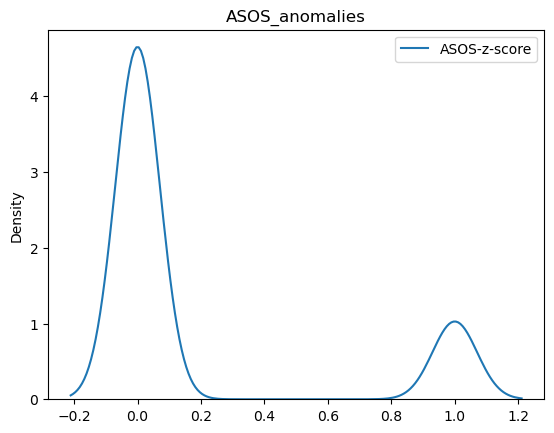

In [41]:
sns.kdeplot(ASOS_anomalies)
plt.title('ASOS_anomalies')
plt.show()

Now the final move, plot the PODs for abnormal users.
<br/>
What does it mean? Write your opinion


,POD,AvgSpentOnSnappFood,ASOS-z-score,POD-z-score
0,0.095239,2.931748e+06,-0.749173,-1.165966
1,0.105493,3.517870e+06,0.325485,-1.127797
2,0.123370,3.481772e+06,0.259298,-1.061250
3,0.141007,3.531373e+06,0.350242,-0.995597
4,0.102860,3.440841e+06,0.184252,-1.137600


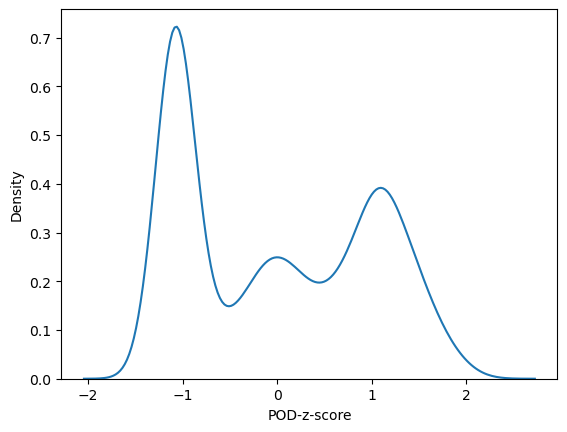

In [42]:
# YOUR CODE HERE

df["POD-z-score"] = df[['POD']].apply(stats.zscore)
display(df.head())

sns.kdeplot(df['POD-z-score'])
plt.show()


,POD-z-score
0,False
1,False
2,False
3,False
4,False
...,...
4938,False
4939,False
4940,False
4941,False


Total True values in DataFrame: 973


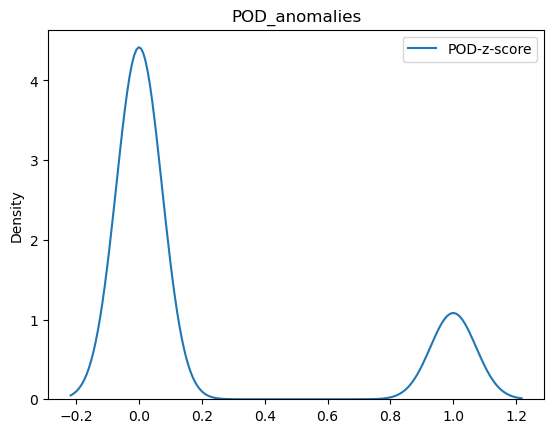

In [43]:
POD_anomalies = pd.DataFrame(abs(df['POD-z-score'])>=1.2)
display(POD_anomalies)

pod_true_count = POD_anomalies.values.sum()
print("Total True values in DataFrame:", pod_true_count)

sns.kdeplot(POD_anomalies)
plt.title('POD_anomalies')
plt.show()

YOUR OPINION HERE:

### Thank you!